<a href="https://colab.research.google.com/github/davidluz/rag-gestores/blob/New-app/notebook/1_Geracao_Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ✅ Criação dos Embedding

# 🚀 Pipeline de Geração e Avaliação de Modelos de Recomendação

**Objetivo:** Este notebook implementa um fluxo de trabalho completo e rastreável para:
1.  **Processar** a base de dados de materiais (ODAs).
2.  **Gerar** embeddings de texto enriquecidos e um índice de busca FAISS.
3.  **Avaliar** o modelo gerado usando métricas de aproximação e análise qualitativa.
4.  **Registrar** todo o processo (parâmetros, métricas, gráficos e modelos) como um experimento no **MLflow**.

In [ ]:
# Instala as bibliotecas necessárias no ambiente do Colab
!pip install faiss-cpu
!pip install sentence-transformers -q
!pip install pandas openpyxl -q
!pip install mlflow -q
!pip install pyngrok -q
!pip install umap-learn -q

In [ ]:
# Importações do Python
import os
import pickle
import re
import time
import subprocess
from pathlib import Path
from typing import Dict, Any, Tuple, Optional, List

# Importações de bibliotecas de dados e ML
import pandas as pd
import numpy as np
import faiss
import mlflow
import torch
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import seaborn as sns
from pyngrok import ngrok
import umap

# Configura um estilo visual mais agradável para os gráficos
sns.set_theme(style="whitegrid")
print("✅ Bibliotecas importadas.")

✅ Bibliotecas importadas.


In [ ]:
# Conecta o Colab ao seu Google Drive para ler e salvar arquivos
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
**Atenção:** Esta é a única célula que você precisa alterar para cada novo experimento.
Defina a versão do modelo e os nomes dos arquivos.

In [ ]:
# --- PARÂMETROS PRINCIPAIS ---
MODELO_VERSAO = "v5_avaliacao_completa"
GDRIVE_PROJECT_PATH = "/content/drive/MyDrive/PROJETO_MORI_GDRIVE"
INPUT_XLSX_NAME = "Base_de_ODAS_1606.xlsx"
EMBEDDING_MODEL = "nomic-ai/nomic-embed-text-v1.5"
BATCH_SIZE = 16

# --- Perfis para o Teste Automático ---
PERFIS_DE_TESTE = [
    ("Gestor_Intermediario_DPD", 17, "Dimensão pedagógica", "Desenvolvimento profissional docente"),
    ("Gestor_Avancado_DPD", 45, "Dimensão pedagógica", "Desenvolvimento profissional docente"),
]

# --- CAMINHOS GERADOS AUTOMATICAMENTE ---
caminho_xlsx_input = os.path.join(GDRIVE_PROJECT_PATH, "data_source", INPUT_XLSX_NAME)
pasta_output_models = os.path.join(GDRIVE_PROJECT_PATH, "models_output", MODELO_VERSAO)
os.makedirs(pasta_output_models, exist_ok=True)
caminho_metadados_output = os.path.join(pasta_output_models, f"metadados_odas.pkl")
caminho_index_output = os.path.join(pasta_output_models, f"odas_index.faiss")

print(f"Versão do Modelo a ser gerada: {MODELO_VERSAO}")

Versão do Modelo a ser gerada: v5_avaliacao_completa


In [ ]:
def preparar_texto_oda_enriquecido(row: pd.Series) -> str:
    header = f"Contexto: Público '{row.get('Público-Alvo', 'Geral')}', Rubrica '{row.get('Rubrica_IA', 'N/A')}'."
    partes = [header, f"Título: {row.get('Título', '')}", f"Resumo completo: {row.get('Resumo completo', '')}", f"Temas: {row.get('Temas', '')}"]
    return "\n".join([p for p in partes if pd.notnull(p) and str(p).strip() and 'nan' not in str(p).lower()])

def gerar_embedding_para_rag(modelo: SentenceTransformer, texto: str, device: str) -> np.ndarray:
    embedding = modelo.encode([texto], device=device)
    return embedding / np.linalg.norm(embedding, axis=1, keepdims=True)

def gerar_card_html(row: pd.Series) -> str:
    titulo = row.get("Título", "Sem título")
    resumo = str(row.get("Resumo", "Sem resumo")).strip()
    suporte = row.get("Suporte", "Não informado")
    distancia = row.get('distância', 0.0)
    return f"""
    <div style="border: 1px solid #e1e4e8; border-radius: 6px; padding: 16px; margin-bottom: 16px;">
        <h4 style="margin-top: 0;">{titulo}</h4>
        <p><strong>Resumo:</strong> {resumo}</p>
        <p><strong>Suporte:</strong> {suporte} | <strong>Score de Relevância:</strong> {distancia:.4f}</p>
    </div>
    """

def avaliar_modelo(perfil_teste: tuple, modelo, index, metadados, df_devolutivas, df_rubricas, device: str) -> Tuple[Dict[str, float], str]:
    _, pontuacao, dimensao, subdimensao = perfil_teste

    # Simula a geração do texto rico do app
    item_devolutiva = df_devolutivas[(df_devolutivas["Dimensão"] == dimensao) & (df_devolutivas["Subdimensão"] == subdimensao)].iloc[0]
    texto_rico = f"Necessidades formativas:\n{item_devolutiva['Necessidades formativas']}".strip()

    if not texto_rico: return {}, "<h3>Erro ao gerar texto rico</h3>"

    embedding_query = gerar_embedding_para_rag(modelo, texto_rico, device)
    distancias, indices = index.search(embedding_query.astype("float32"), k=500)

    resultados = metadados.iloc[indices[0]].copy()
    resultados["distância"] = distancias[0]

    # Lógica de Balanceamento
    condicoes = [
        resultados['Suporte'].str.contains(r"jogo|painel", case=False, na=False),
        resultados['Suporte'].str.contains(r"infográfico|mapa|tabela|gráfico|slide", case=False, na=False),
        resultados['Suporte'].str.contains(r"vídeo|video|curso|aula", case=False, na=False),
        resultados['Suporte'].str.contains(r"áudio|audio|podcast|rádio", case=False, na=False),
        resultados['Suporte'].str.contains(r"texto|artigo|livro", case=False, na=False)
    ]
    categorias_map = ["interativos", "visuais", "videos", "audios", "artigos"]
    resultados['categoria'] = np.select(condicoes, categorias_map, default='outros')
    resultados_balanceados = resultados[resultados['categoria'] != 'outros'].groupby('categoria').head(10)

    # Calcula métricas e gera relatório
    scores_por_categoria = {}
    html_report = f"<h1>Resultados para: {perfil_teste[0]}</h1>"

    for cat in categorias_map:
        df_cat = resultados_balanceados[resultados_balanceados['categoria'] == cat]
        if not df_cat.empty:
            score_medio = df_cat['distância'].mean()
            scores_por_categoria[f"avg_sim_{cat}"] = score_medio
            html_report += f"<h2>📚 {cat.capitalize()} (Score Médio: {score_medio:.4f})</h2>"
            for _, row in df_cat.iterrows():
                html_report += gerar_card_html(row)

    return scores_por_categoria, html_report

print("✅ Funções auxiliares definidas.")

✅ Funções auxiliares definidas.


🚀 Iniciando Run: v5_avaliacao_completa (ID: 379510495e504b4ab3da594f25eb5a4c)

[ETAPA 1/5] Carregando e Processando Dados...

[ETAPA 2/5] Gerando Gráficos de Análise...

[ETAPA 3/5] Gerando Embeddings e Índice FAISS...


Batches:   0%|          | 0/527 [00:00<?, ?it/s]


[ETapa 4/5] Salvando Artefatos do Modelo...

[ETAPA 5/5] Avaliando o Modelo Gerado...

✅ Experimento v5_avaliacao_completa finalizado!
   Métrica Geral (Média de todas as categorias): 0.7535


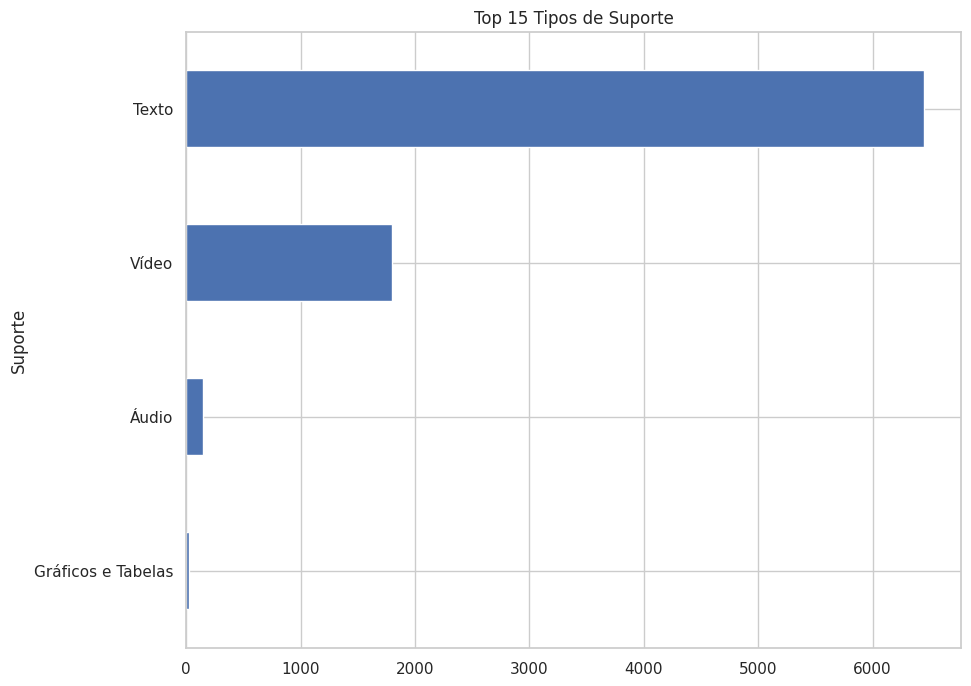

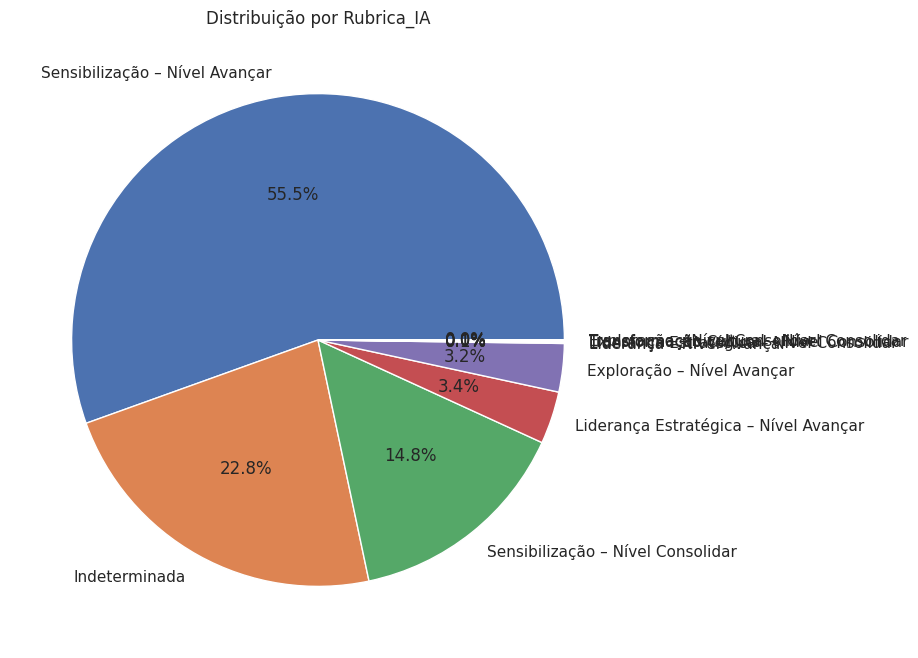

In [ ]:
# Esta célula executa todo o processo, do início ao fim.

mlflow.set_tracking_uri(f"file:{os.path.join(GDRIVE_PROJECT_PATH, 'mlflow_tracking')}")
mlflow.set_experiment("Recomendacao_Mori_Pipeline")

with mlflow.start_run(run_name=f"Treino_Versao_{MODELO_VERSAO}") as run:
    print(f"🚀 Iniciando Run: {MODELO_VERSAO} (ID: {run.info.run_id})")
    mlflow.log_params({"versao_modelo": MODELO_VERSAO, "embedding_model": EMBEDDING_MODEL, "batch_size": BATCH_SIZE})

    print("\n[ETAPA 1/5] Carregando e Processando Dados...")
    df_odas = pd.read_excel(caminho_xlsx_input)
    df_odas.dropna(subset=["Resumo completo", "Temas", "Dimensões", "Tipo"], inplace=True)
    df_odas["texto_completo"] = df_odas.apply(preparar_texto_oda_enriquecido, axis=1)

    print("\n[ETAPA 2/5] Gerando Gráficos de Análise...")
    fig_suporte, ax1 = plt.subplots(figsize=(10, 8)); df_odas['Suporte'].value_counts().head(15).sort_values().plot(kind='barh', ax=ax1); ax1.set_title('Top 15 Tipos de Suporte'); mlflow.log_figure(fig_suporte, "analise_exploratoria/1_distribuicao_suporte.png")
    if 'Rubrica_IA' in df_odas.columns:
        fig_rubrica, ax2 = plt.subplots(figsize=(10, 8)); df_odas['Rubrica_IA'].value_counts().plot(kind='pie', autopct='%1.1f%%'); ax2.set_title('Distribuição por Rubrica_IA'); ax2.set_ylabel(''); mlflow.log_figure(fig_rubrica, "analise_exploratoria/2_distribuicao_rubrica_ia.png")

    print("\n[ETAPA 3/5] Gerando Embeddings e Índice FAISS...")
    device = "cuda" if torch.cuda.is_available() else "cpu"
    mlflow.log_param("device", device)
    # Linha corrigida
    modelo = SentenceTransformer(EMBEDDING_MODEL, device=device, trust_remote_code=True)
    embeddings = modelo.encode(df_odas["texto_completo"].tolist(), batch_size=BATCH_SIZE, show_progress_bar=True)
    embeddings_norm = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
    index = faiss.IndexFlatIP(embeddings_norm.shape[1]); index.add(embeddings_norm.astype("float32"))

    print("\n[ETapa 4/5] Salvando Artefatos do Modelo...")
    metadados = df_odas[[c for c in df_odas.columns if c != 'texto_completo']].reset_index(drop=True)
    with open(caminho_metadados_output, "wb") as f: pickle.dump(metadados, f)
    faiss.write_index(index, str(caminho_index_output))
    mlflow.log_artifacts(str(pasta_output_models), artifact_path="model_artifacts")

    print("\n[ETAPA 5/5] Avaliando o Modelo Gerado...")
    df_devolutivas = pd.read_csv(os.path.join(GDRIVE_PROJECT_PATH, "data_source", "devolutivas.csv"), sep=";")
    df_devolutivas.rename(columns={"Necessidaes formativas": "Necessidades formativas"}, inplace=True)
    df_rubricas = pd.read_csv(os.path.join(GDRIVE_PROJECT_PATH, "data_source", "rubricas.csv"), sep=";")

    metricas_gerais = []
    for perfil in PERFIS_DE_TESTE:
        scores, report_html = avaliar_modelo(perfil, modelo, index, metadados, df_devolutivas, df_rubricas, device)
        metricas_gerais.append(scores)
        report_path = f"relatorio_{perfil[0]}.html"
        with open(report_path, "w", encoding="utf-8") as f: f.write(report_html)
        mlflow.log_artifact(report_path, "relatorios_qualitativos")

    df_metricas = pd.DataFrame(metricas_gerais)
    mlflow.log_metrics(df_metricas.mean().to_dict()) # Loga a média de cada categoria

    print("\n" + "="*50)
    print(f"✅ Experimento {MODELO_VERSAO} finalizado!")
    print(f"   Métrica Geral (Média de todas as categorias): {df_metricas.mean().mean():.4f}")
    print("="*50)

In [ ]:
# Roda esta célula para iniciar o painel de controle e obter um link público
# Cole seu authtoken do ngrok aqui
NGROK_AUTHTOKEN = ""
ngrok.set_auth_token(NGROK_AUTHTOKEN)

# Inicia o servidor MLflow em segundo plano
mlflow_process = subprocess.Popen(["mlflow", "ui", "--backend-store-uri", mlflow.get_tracking_uri(), "--host", "127.0.0.1"])

print("Aguardando o servidor do MLflow iniciar (10 segundos)...")
time.sleep(10)

# Cria o túnel e exibe o link
try:
    public_url = ngrok.connect(5000)
    print("="*80)
    print(f"✅ PAINEL DO MLFLOW NO AR! CLIQUE NESTE LINK:\n{public_url}")
    print("="*80)
except Exception as e:
    print(f"❌ Erro ao iniciar o ngrok: {e}")

Aguardando o servidor do MLflow iniciar (10 segundos)...
✅ PAINEL DO MLFLOW NO AR! CLIQUE NESTE LINK:
NgrokTunnel: "https://31fa-34-124-158-126.ngrok-free.app" -> "http://localhost:5000"
